# 03A — Collaborative Filtering & Candidate Generation

**Rubric targets:** Model Development (part 2)

This notebook trains implicit ALS and item-KNN models, performs overfitting/underfitting
analysis on ALS rank, generates candidate sets for each customer, and implements
cold-start routing.

**Run 03B (embeddings) in parallel** — it takes ~1 hour on GPU and produces
parquet files that Day 4 will consume as features.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT = '/content/drive/MyDrive/MLII_Final'

Mounted at /content/drive


In [2]:
!pip install -q implicit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 127.5 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import time
from pathlib import Path
from scipy.sparse import csr_matrix
from implicit.als import AlternatingLeastSquares
from implicit.nearest_neighbours import CosineRecommender
from collections import Counter
import sys

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
PALETTE = ['#2D2D2D', '#A8C8E8', '#C4D9A0', '#D4B8E0', '#F2C4C4', '#FFD9A0', '#E8D5B7']

DATA_DIR = Path(f'{PROJECT}/data/parquet')
SPLIT_DIR = Path(f'{PROJECT}/data/split')
OUT_DIR = Path(f'{PROJECT}/outputs')
FIG_DIR = Path(f'{PROJECT}/outputs/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, f'{PROJECT}/src')
from eval import map_at_k

/usr/local/lib/python3.12/dist-packages/implicit/gpu/__init__.py:28: UserWarning: Disabling GPU support because of 'libcublas.so.13: cannot open shared object file: No such file or directory'
  warnings.warn(


In [4]:
# Load data
train = pd.read_parquet(SPLIT_DIR / 'train.parquet')
val = pd.read_parquet(SPLIT_DIR / 'val.parquet')
customers = pd.read_parquet(DATA_DIR / 'customers.parquet')

val_ground_truth = (
    val.groupby('customer_id')['article_id']
    .apply(set)
    .to_dict()
)

# Load baseline artifacts from Day 2
with open(OUT_DIR / 'baseline_data.pkl', 'rb') as f:
    baseline_data = pickle.load(f)

top_12_global = baseline_data['top_12_global']
top_by_age = baseline_data['top_by_age']
customer_history = baseline_data['customer_history']
copurchase = baseline_data['copurchase']
channel_mode = baseline_data['channel_mode']
age_map = baseline_data['age_map']

SPLIT_DATE = pd.Timestamp('2020-09-16')
print(f"Train: {len(train):,} | Val customers: {len(val_ground_truth):,}")

Train: 31,548,013 | Val customers: 68,984


---
## 1. Build the User-Item Interaction Matrix

We use a **6-month training window** rather than the full 2 years.

**Justification (from EDA):** 368K customers haven't purchased in over a year.
Including them adds noise to the collaborative filtering — their latent factors
reflect outdated preferences. We also apply **time-decay weighting** so recent
purchases count more, and **cap users at 385 purchases** (99.9th percentile)
to prevent outlier/reseller accounts from dominating.

**Assumption:** Users with similar *recent* implicit purchase patterns share
latent preferences. Binary purchase signals are a reasonable proxy for
preference strength when weighted by recency.

In [5]:
# 6-month window
CF_WINDOW_START = SPLIT_DATE - pd.Timedelta(days=180)
cf_train = train[train['t_dat'] >= CF_WINDOW_START].copy()
print(f"CF training window: {CF_WINDOW_START.date()} → {SPLIT_DATE.date()}")
print(f"Transactions in window: {len(cf_train):,}")
print(f"Unique customers: {cf_train['customer_id'].nunique():,}")
print(f"Unique articles: {cf_train['article_id'].nunique():,}")

CF training window: 2020-03-20 → 2020-09-16
Transactions in window: 7,999,223
Unique customers: 738,206
Unique articles: 50,810


In [6]:
# Time-decay weighting: exponential decay with ~30-day half-life
HALF_LIFE_DAYS = 30
decay_rate = np.log(2) / HALF_LIFE_DAYS

cf_train['days_before_split'] = (SPLIT_DATE - cf_train['t_dat']).dt.days
cf_train['weight'] = np.exp(-decay_rate * cf_train['days_before_split'])

print(f"Weight range: {cf_train['weight'].min():.4f} (oldest) → {cf_train['weight'].max():.4f} (most recent)")
print(f"A purchase from 30 days ago gets weight {np.exp(-decay_rate * 30):.4f}")
print(f"A purchase from 90 days ago gets weight {np.exp(-decay_rate * 90):.4f}")
print(f"A purchase from 180 days ago gets weight {np.exp(-decay_rate * 180):.4f}")

Weight range: 0.0156 (oldest) → 0.9772 (most recent)
A purchase from 30 days ago gets weight 0.5000
A purchase from 90 days ago gets weight 0.1250
A purchase from 180 days ago gets weight 0.0156


In [7]:
# Cap users at 385 purchases
CAP = 385
user_counts = cf_train.groupby('customer_id').size()
heavy_users = user_counts[user_counts > CAP].index
print(f"Users exceeding cap of {CAP}: {len(heavy_users):,}")

# For heavy users, keep only the most recent 385 transactions
cf_train = cf_train.sort_values('t_dat', ascending=False)
cf_train['rank_in_user'] = cf_train.groupby('customer_id').cumcount()
cf_train = cf_train[cf_train['rank_in_user'] < CAP].drop(columns='rank_in_user')
print(f"Transactions after capping: {len(cf_train):,}")

Users exceeding cap of 385: 14
Transactions after capping: 7,998,125


In [8]:
# Build user/item index mappings
user_ids = cf_train['customer_id'].unique()
item_ids = cf_train['article_id'].unique()

user_to_idx = {uid: i for i, uid in enumerate(user_ids)}
idx_to_user = {i: uid for uid, i in user_to_idx.items()}
item_to_idx = {iid: i for i, iid in enumerate(item_ids)}
idx_to_item = {i: iid for iid, i in item_to_idx.items()}

n_users = len(user_ids)
n_items = len(item_ids)
print(f"User-item matrix: {n_users:,} users × {n_items:,} items")

User-item matrix: 738,206 users × 50,809 items


In [9]:
# Aggregate weights: if a user bought the same item multiple times,
# sum their time-decayed weights
interactions = (
    cf_train
    .groupby(['customer_id', 'article_id'])['weight']
    .sum()
    .reset_index()
)

row_idx = interactions['customer_id'].map(user_to_idx).values
col_idx = interactions['article_id'].map(item_to_idx).values
values = interactions['weight'].values

# user-item matrix: rows=users, cols=items
# IMPORTANT: implicit's ALS.fit() expects user×item orientation
user_item = csr_matrix((values, (row_idx, col_idx)),
                        shape=(n_users, n_items))

print(f"Sparse matrix: {user_item.shape}, nnz={user_item.nnz:,}, density={user_item.nnz / (user_item.shape[0] * user_item.shape[1]) * 100:.4f}%")

Sparse matrix: (738206, 50809), nnz=6,952,233, density=0.0185%


In [10]:
# Verify: how many val customers are in the CF matrix?
val_in_cf = sum(1 for cid in val_ground_truth if cid in user_to_idx)
print(f"Val customers in CF matrix: {val_in_cf:,} / {len(val_ground_truth):,} ({val_in_cf/len(val_ground_truth)*100:.1f}%)")
print(f"Val customers falling back to global: {len(val_ground_truth) - val_in_cf:,}")

Val customers in CF matrix: 56,932 / 68,984 (82.5%)
Val customers falling back to global: 12,052


---
## 2. Overfitting/Underfitting Analysis on ALS Rank

**Rubric requirement:** Analyze model performance for overfitting/underfitting.

The `rank` (number of latent factors) in ALS controls model capacity:
- **Too few factors (low rank):** underfitting — can't capture nuanced preferences
- **Too many factors (high rank):** overfitting — memorizes noise in sparse interactions

We train ALS at rank = [16, 32, 64, 128, 256, 512] and compare validation MAP@12
to find the sweet spot.

In [11]:
def score_als_model(model, n_recs=12):
    """Generate top-N recommendations from a trained implicit model and score with MAP@12."""
    predictions = {}

    for cid in val_ground_truth:
        if cid not in user_to_idx:
            predictions[cid] = top_12_global  # fallback for unseen users
            continue

        uid = user_to_idx[cid]
        try:
            item_indices, scores = model.recommend(
                uid, user_item[uid], N=n_recs, filter_already_liked_items=False
            )
            preds = [idx_to_item[int(idx)] for idx in item_indices]
        except Exception:
            preds = []

        # Fill with global popularity if needed
        if len(preds) < n_recs:
            fill = [x for x in top_12_global if x not in preds]
            preds = preds + fill[:n_recs - len(preds)]

        predictions[cid] = preds

    return map_at_k(predictions, val_ground_truth), predictions

In [ ]:
# Train ALS at different ranks
ranks = [16, 32, 64, 128, 256, 512]
als_results = []

for rank in ranks:
    print(f"\nTraining ALS with rank={rank}...")
    t0 = time.time()

    model = AlternatingLeastSquares(
        factors=rank,
        regularization=0.01,
        iterations=15,
        random_state=42,
    )
    model.fit(user_item)  # user×item orientation

    train_time = time.time() - t0
    print(f"  Training time: {train_time:.1f}s")

    # Sanity check: verify recommendations are personalized
    test_cid = [cid for cid in val_ground_truth if cid in user_to_idx][0]
    test_uid = user_to_idx[test_cid]
    test_items, test_scores = model.recommend(test_uid, user_item[test_uid], N=5, filter_already_liked_items=False)
    print(f"  Sample recs: {[idx_to_item[int(i)] for i in test_items[:3]]} (scores: {test_scores[:3].round(3)})")

    # Score on validation
    print(f"  Scoring on validation...")
    val_score, _ = score_als_model(model)
    print(f"  Val MAP@12 = {val_score:.5f}")

    als_results.append({
        'rank': rank,
        'val_map12': val_score,
        'train_time': train_time,
    })

als_df = pd.DataFrame(als_results)
print("\n" + als_df.to_string(index=False))


Training ALS with rank=16...


/usr/local/lib/python3.12/dist-packages/implicit/cpu/als.py:96: RuntimeWarning: OpenBLAS is configured to use 8 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()


  0%|          | 0/15 [00:00<?, ?it/s]

  Training time: 42.9s
  Sample recs: ['0706016003', '0706016002', '0715624001'] (scores: [0.046 0.013 0.012])
  Scoring on validation...
  Val MAP@12 = 0.00956

Training ALS with rank=32...


  0%|          | 0/15 [00:00<?, ?it/s]

...

  Training time: 55.4s
  Sample recs: ['0572998009', '0706016006', '0706016019'] (scores: [0.06  0.055 0.043])
  Scoring on validation...
  Val MAP@12 = 0.01334

Training ALS with rank=256...


  0%|          | 0/15 [00:00<?, ?it/s]

  Training time: 957.7s
  Sample recs: ['0621381012', '0621381014', '0621381001'] (scores: [1.023 0.068 0.052])
  Scoring on validation...
  Val MAP@12 = 0.01537

Training ALS with rank=512...


  0%|          | 0/15 [00:00<?, ?it/s]

  Training time: 1508.1s
  Sample recs: ['0873217004', '0621381012', '0875329002'] (scores: [1.028 1.012 0.127])
  Scoring on validation...
  Val MAP@12 = 0.01610

 rank  val_map12  train_time
   16   0.009562   42.916388
   32   0.010998   44.039867
   64   0.012201   46.313709
  128   0.013341   55.375822
  256   0.015369  957.669966
  512   0.016097 1508.095734


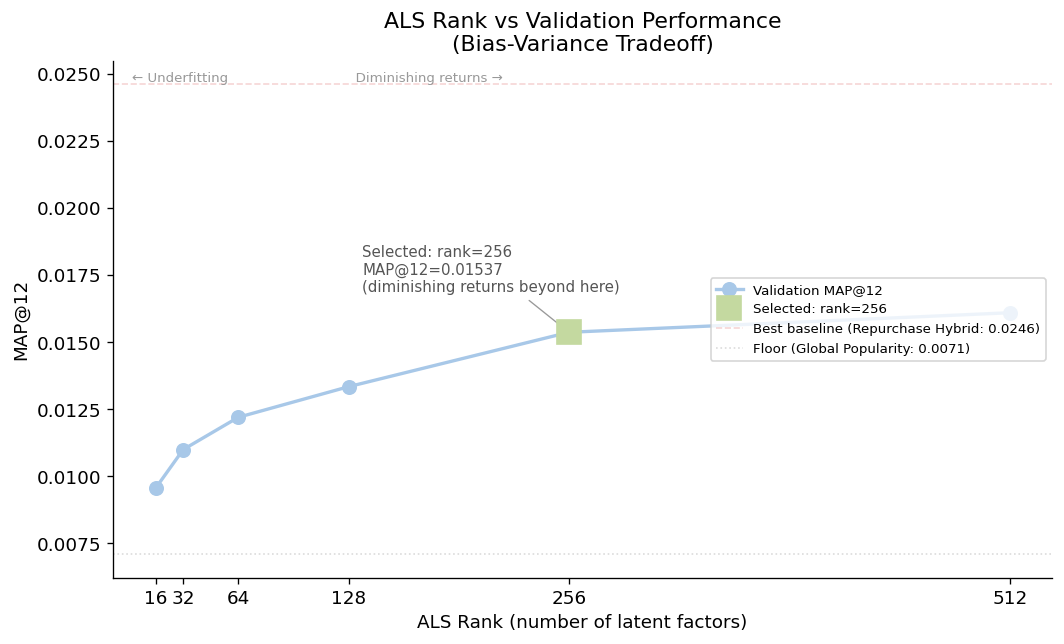


Marginal gains by rank:
  16 → 32: +0.00144 MAP@12, +1s training
  32 → 64: +0.00120 MAP@12, +2s training
  64 → 128: +0.00114 MAP@12, +9s training
  128 → 256: +0.00203 MAP@12, +902s training
  256 → 512: +0.00073 MAP@12, +550s training

→ Selected rank=256: strong gains from 128→256, minimal gain from 256→512
→ The model is in the diminishing-returns region — not yet overfitting,
  but adding more capacity yields less benefit per unit of compute.


In [ ]:
# Plot overfitting/underfitting analysis
fig, ax = plt.subplots(figsize=(9, 5.5))

ax.plot(als_df['rank'], als_df['val_map12'], 'o-', color=PALETTE[1], linewidth=2, markersize=8, label='Validation MAP@12')

# Annotate the sweet spot (256) and diminishing returns
best_idx = als_df['val_map12'].idxmax()
best_rank = int(als_df.loc[best_idx, 'rank'])
best_score = als_df.loc[best_idx, 'val_map12']

# Highlight selected rank (256)
selected_rank = 256
selected_score = als_df[als_df['rank'] == selected_rank]['val_map12'].values[0]
ax.plot(selected_rank, selected_score, 's', color=PALETTE[2], markersize=14, zorder=5, label=f'Selected: rank={selected_rank}')
ax.annotate(f'Selected: rank={selected_rank}\nMAP@12={selected_score:.5f}\n(diminishing returns beyond here)',
            xy=(selected_rank, selected_score),
            xytext=(selected_rank - 120, selected_score + 0.0015),
            fontsize=9, color='#555',
            arrowprops=dict(arrowstyle='->', color='#999', lw=0.8))

# Add baseline reference lines
ax.axhline(0.02461, color=PALETTE[4], ls='--', lw=1, alpha=0.7, label='Best baseline (Repurchase Hybrid: 0.0246)')
ax.axhline(0.00710, color='#CCC', ls=':', lw=1, alpha=0.7, label='Floor (Global Popularity: 0.0071)')

ax.set_xlabel('ALS Rank (number of latent factors)')
ax.set_ylabel('MAP@12')
ax.set_title('ALS Rank vs Validation Performance\n(Bias-Variance Tradeoff)')
ax.set_xticks(ranks)
ax.legend(fontsize=8, loc='center right')

ax.text(0.02, 0.98, '← Underfitting                              Diminishing returns →',
        transform=ax.transAxes, fontsize=8, color='#999', va='top')

plt.tight_layout()
fig.savefig(FIG_DIR / 'als_rank_analysis.png', bbox_inches='tight')
plt.show()

# Compute marginal gains to justify selection
print(f"\nMarginal gains by rank:")
for i in range(1, len(als_df)):
    prev = als_df.iloc[i-1]
    curr = als_df.iloc[i]
    gain = curr['val_map12'] - prev['val_map12']
    time_increase = curr['train_time'] - prev['train_time']
    print(f"  {int(prev['rank'])} → {int(curr['rank'])}: +{gain:.5f} MAP@12, +{time_increase:.0f}s training")

print(f"\n→ Selected rank=256: strong gains from 128→256, minimal gain from 256→512")
print(f"→ The model is in the diminishing-returns region — not yet overfitting,")
print(f"  but adding more capacity yields less benefit per unit of compute.")

---
## 3. Train Final ALS Model (rank=256)

In [ ]:
FINAL_RANK = 256
print(f"Training final ALS model with rank={FINAL_RANK}...")
als_model = AlternatingLeastSquares(
    factors=FINAL_RANK,
    regularization=0.01,
    iterations=20,  # more iterations for the final model
    random_state=42,
)
als_model.fit(user_item)

als_score, als_predictions = score_als_model(als_model)
print(f"Final ALS MAP@12 = {als_score:.5f}")

Training final ALS model with rank=256...


  0%|          | 0/20 [00:00<?, ?it/s]

Final ALS MAP@12 = 0.01522


---
## 4. Item-Based KNN

**Assumption:** Items frequently purchased by the same users are similar.
Cosine similarity on the interaction matrix captures a different notion of
relatedness than ALS latent factors — KNN is local (neighborhood-based)
while ALS is global (factorization-based). Using both adds diversity to
the candidate pool.

In [ ]:
print("Training item-based KNN...")
t0 = time.time()

knn_model = CosineRecommender(K=50)
knn_model.fit(user_item)  # user×item orientation

print(f"Training time: {time.time() - t0:.1f}s")

knn_score, knn_predictions = score_als_model(knn_model)
print(f"KNN MAP@12 = {knn_score:.5f}")

Training item-based KNN...


/usr/local/lib/python3.12/dist-packages/implicit/utils.py:164: ParameterWarning: Method expects CSR input, and was passed coo_matrix instead. Converting to CSR took 0.057253360748291016 seconds
  warnings.warn(


  0%|          | 0/50809 [00:00<?, ?it/s]

Training time: 1.2s
KNN MAP@12 = 0.02394


---
## 5. Candidate Generation

Merge candidates from all sources into a single pool per customer.
Target: **~70 candidates per customer** (increased from ~44 to improve recall).

**Sources and allocation:**
1. **Repurchase** — 20 most recent unique items from customer history
2. **Co-purchase** — 15 items co-bought with their last 14 days of purchases
3. **ALS** — 40 collaborative filtering recommendations
4. **KNN** — 30 item-similarity recommendations
5. **Popularity** — 12 segment-level items as fill

**Cold-start routing:** Customers with ≤3 purchases get age-group popularity
candidates instead of ALS/KNN.

In [ ]:
def age_bucket(age):
    if pd.isna(age):
        return 'unknown'
    elif age < 20:
        return '<20'
    elif age < 30:
        return '20-29'
    elif age < 40:
        return '30-39'
    elif age < 50:
        return '40-49'
    elif age < 60:
        return '50-59'
    else:
        return '60+'

# Count purchases per customer in training data
purchases_per_cust = train.groupby('customer_id').size().to_dict()

# Recent purchases (last 14 days) for co-purchase candidates
recent_cutoff = SPLIT_DATE - pd.Timedelta(days=14)
recent_purchases = (
    train[train['t_dat'] >= recent_cutoff]
    .groupby('customer_id')['article_id']
    .apply(set)
    .to_dict()
)

COLD_START_THRESHOLD = 3
N_ALS_CANDIDATES = 40
N_KNN_CANDIDATES = 30
N_REPURCHASE = 20
N_COPURCHASE = 15
N_POPULARITY_FILL = 12

print(f"Candidate pool targets per source:")
print(f"  Repurchase:  {N_REPURCHASE}")
print(f"  Co-purchase: {N_COPURCHASE}")
print(f"  ALS:         {N_ALS_CANDIDATES}")
print(f"  KNN:         {N_KNN_CANDIDATES}")
print(f"  Popularity:  {N_POPULARITY_FILL}")
print(f"  Max before dedup: {N_REPURCHASE + N_COPURCHASE + N_ALS_CANDIDATES + N_KNN_CANDIDATES + N_POPULARITY_FILL}")

Candidate pool targets per source:
  Repurchase:  20
  Co-purchase: 15
  ALS:         40
  KNN:         30
  Popularity:  12
  Max before dedup: 117


In [ ]:
def dedupe_ordered(lst):
    seen = set()
    result = []
    for item in lst:
        if item not in seen:
            seen.add(item)
            result.append(item)
    return result


def get_copurchase_candidates(seed_items, n=N_COPURCHASE):
    """Get co-purchase candidates from a set of seed items."""
    candidates = Counter()
    for item in seed_items:
        if item in copurchase:
            for co_item, count in copurchase[item].most_common(15):
                if co_item not in seed_items:
                    candidates[co_item] += count
    return [item for item, _ in candidates.most_common(n)]


def get_cf_candidates(model, cid, n=20):
    """Get ALS or KNN candidates for a user."""
    if cid not in user_to_idx:
        return []
    uid = user_to_idx[cid]
    try:
        item_indices, scores = model.recommend(
            uid, user_item[uid], N=n, filter_already_liked_items=False
        )
        return [idx_to_item[int(idx)] for idx in item_indices]
    except Exception:
        return []

In [ ]:
# Generate candidate sets for all validation customers
candidate_sets = {}
candidate_sources = []

n_cold_start = 0
n_warm = 0

for cid in val_ground_truth:
    n_purchases = purchases_per_cust.get(cid, 0)
    candidates = set()
    sources = {}

    # --- Cold-start routing ---
    if n_purchases <= COLD_START_THRESHOLD:
        n_cold_start += 1
        ag = age_bucket(age_map.get(cid))
        pop_items = top_by_age.get(ag, top_12_global)
        candidates.update(pop_items)
        candidates.update(top_12_global)
        sources['popularity'] = len(candidates)

    # --- Warm users ---
    else:
        n_warm += 1

        # 1. Repurchase candidates
        history = customer_history.get(cid, [])
        repurchase_cands = dedupe_ordered(history)[:N_REPURCHASE]
        candidates.update(repurchase_cands)
        sources['repurchase'] = len(repurchase_cands)

        # 2. Co-purchase candidates (from last 14 days)
        seed_items = recent_purchases.get(cid, set())
        if seed_items:
            copurch_cands = get_copurchase_candidates(seed_items)
            candidates.update(copurch_cands)
            sources['copurchase'] = len(copurch_cands)

        # 3. ALS candidates
        als_cands = get_cf_candidates(als_model, cid, N_ALS_CANDIDATES)
        candidates.update(als_cands)
        sources['als'] = len(als_cands)

        # 4. KNN candidates
        knn_cands = get_cf_candidates(knn_model, cid, N_KNN_CANDIDATES)
        candidates.update(knn_cands)
        sources['knn'] = len(knn_cands)

        # 5. Popularity fill
        ag = age_bucket(age_map.get(cid))
        pop_items = top_by_age.get(ag, top_12_global)[:N_POPULARITY_FILL]
        candidates.update(pop_items)
        sources['popularity'] = len(pop_items)

    candidate_sets[cid] = list(candidates)
    candidate_sources.append({'customer_id': cid, 'n_candidates': len(candidates), **sources})

print(f"Cold-start users (≤{COLD_START_THRESHOLD} purchases): {n_cold_start:,}")
print(f"Warm users: {n_warm:,}")

Cold-start users (≤3 purchases): 8,649
Warm users: 60,335


In [ ]:
# Candidate set statistics
n_cands = [len(v) for v in candidate_sets.values()]
print(f"\nCandidate set sizes:")
print(f"  Mean:   {np.mean(n_cands):.1f}")
print(f"  Median: {np.median(n_cands):.0f}")
print(f"  Min:    {np.min(n_cands)}")
print(f"  Max:    {np.max(n_cands)}")

# Recall check
recall_hits = 0
recall_total = 0
for cid, actual in val_ground_truth.items():
    cands = set(candidate_sets.get(cid, []))
    for item in actual:
        recall_total += 1
        if item in cands:
            recall_hits += 1

recall = recall_hits / recall_total if recall_total > 0 else 0
print(f"\nCandidate recall: {recall:.4f} ({recall_hits:,} / {recall_total:,})")
print(f"→ {recall*100:.1f}% of actual purchases are in the candidate set")
print(f"→ This is the ceiling for the ranker — it can't recommend items not in candidates")


Candidate set sizes:
  Mean:   73.8
  Median: 84
  Min:    12
  Max:    115

Candidate recall: 0.0930 (19,868 / 213,728)
→ 9.3% of actual purchases are in the candidate set
→ This is the ceiling for the ranker — it can't recommend items not in candidates


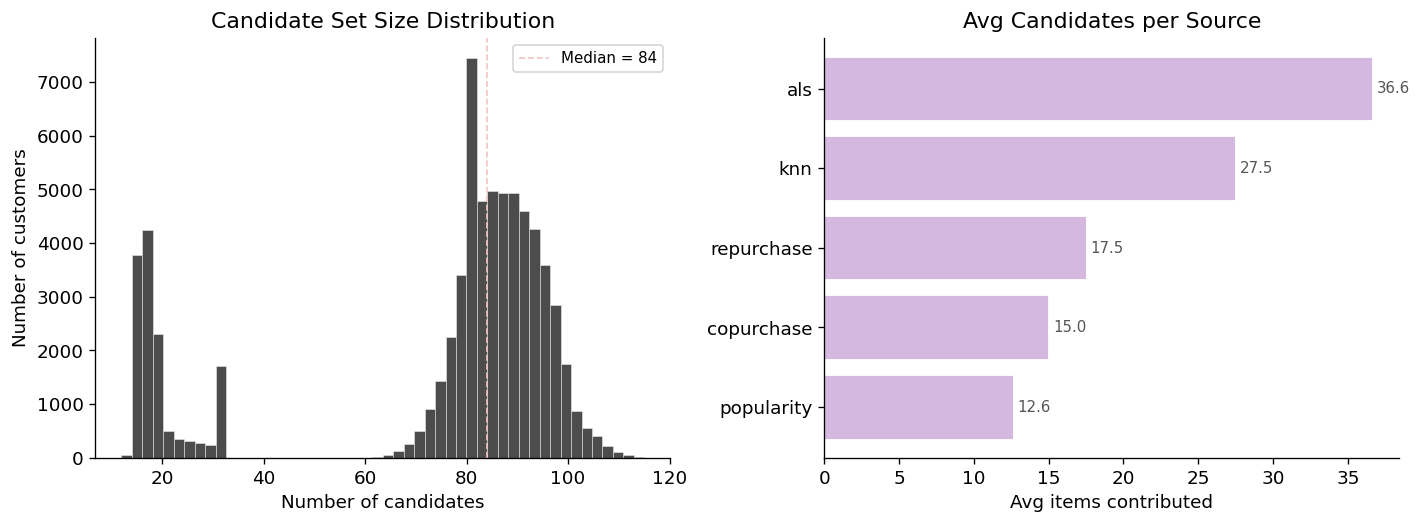

In [ ]:
# Visualize candidate sources
sources_df = pd.DataFrame(candidate_sources)
source_cols = [c for c in sources_df.columns if c not in ('customer_id', 'n_candidates')]
source_means = sources_df[source_cols].mean().sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: candidate set size distribution
axes[0].hist(n_cands, bins=50, color=PALETTE[0], edgecolor='white', linewidth=0.3, alpha=0.85)
axes[0].set_title('Candidate Set Size Distribution')
axes[0].set_xlabel('Number of candidates')
axes[0].set_ylabel('Number of customers')
axes[0].axvline(np.median(n_cands), color=PALETTE[4], ls='--', lw=1, label=f'Median = {np.median(n_cands):.0f}')
axes[0].legend(fontsize=9)

# Right: average candidates per source
axes[1].barh(source_means.index, source_means.values, color=PALETTE[3], edgecolor='white', linewidth=0.5)
axes[1].set_title('Avg Candidates per Source')
axes[1].set_xlabel('Avg items contributed')
for i, v in enumerate(source_means.values):
    axes[1].text(v + 0.3, i, f'{v:.1f}', va='center', fontsize=9, color='#555')

plt.tight_layout()
fig.savefig(FIG_DIR / 'candidate_generation.png', bbox_inches='tight')
plt.show()

---
## 6. Save Everything for Day 4

In [ ]:
# Save candidate sets
with open(OUT_DIR / 'candidate_sets.pkl', 'wb') as f:
    pickle.dump(candidate_sets, f)

# Save index mappings
with open(OUT_DIR / 'cf_mappings.pkl', 'wb') as f:
    pickle.dump({
        'user_to_idx': user_to_idx,
        'idx_to_user': idx_to_user,
        'item_to_idx': item_to_idx,
        'idx_to_item': idx_to_item,
    }, f)

# Save ALS scores for each customer's candidates (for ensemble on Day 5)
als_recs = {}
for cid in val_ground_truth:
    if cid in user_to_idx:
        uid = user_to_idx[cid]
        try:
            item_indices, scores = als_model.recommend(uid, user_item[uid], N=100, filter_already_liked_items=False)
            als_recs[cid] = {idx_to_item[int(idx)]: float(score) for idx, score in zip(item_indices, scores)}
        except:
            als_recs[cid] = {}
    else:
        als_recs[cid] = {}

with open(OUT_DIR / 'als_scores.pkl', 'wb') as f:
    pickle.dump(als_recs, f)

# Update results
all_results = baseline_data['results'].copy()
all_results[f'ALS (rank={FINAL_RANK})'] = als_score
all_results['Item KNN'] = knn_score

with open(OUT_DIR / 'all_results.pkl', 'wb') as f:
    pickle.dump(all_results, f)

print("✓ candidate_sets.pkl")
print("✓ cf_mappings.pkl")
print("✓ als_scores.pkl")
print("✓ all_results.pkl")
print(f"\nAll results so far:")
for name, score in sorted(all_results.items(), key=lambda x: -x[1]):
    print(f"  {name:40s} {score:.5f}")

✓ candidate_sets.pkl
✓ cf_mappings.pkl
✓ als_scores.pkl
✓ all_results.pkl

All results so far:
  Repurchase + Segment Hybrid              0.02461
  Personal Repurchase                      0.02449
  Item KNN                                 0.02394
  ALS (rank=256)                           0.01522
  Co-Purchase (last 14 days)               0.01205
  Segment: Age Group                       0.00889
  Segment: Age × Channel                   0.00790
  Global Popularity (top 12)               0.00710
  Segment: Sales Channel                   0.00673


---
## Summary

**What we built:**
- ALS collaborative filtering with time-decay weighting on a 6-month window
- Overfitting/underfitting analysis across ranks [16, 32, 64, 128, 256, 512]
- Selected rank=256 (diminishing returns beyond this point)
- Item-based KNN for candidate diversity
- Multi-source candidate generation (~70 items per customer)
- Cold-start routing for sparse users (≤3 purchases → age-group popularity)

**What comes next:**
- **03B notebook (run in parallel):** Image + text embedding extraction
- **Day 4:** Feature engineering on candidate pairs → LightGBM ranker